# 잔존수명 예측 모델

입력: 진동 피처 + t_abs(절대 경과 시간) + rpm_pred + initial_fault_intensity
출력: RUL (초)

Train 학습:
  각 1초 샘플의 피처 → 해당 시점의 실제 RUL

Validation 예측:
  마지막 epoch의 피처 → RUL 예측

Train4 : 후방 축방향 결함으로 축방향 하중이 크지만 결함이 특정 방향에 집중되어 전체 베어링 파괴까지 시간이 더 걸렸을 수 있음

In [2]:
# !pip install common_utils


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from common_utils import (load_train_data, load_test_data,
                          get_feat_cols, add_trend_features,
                          calc_score, calc_score_vec,
                          plot_loo_results, TRAIN_PATH, TEST_PATH)

# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset

## 함수 정의

In [3]:
TRAIN_PATH  = '../data/Train'
TEST_PATH   = '../data/Test'

META_COLS = ['epoch', 'window', 't_abs', 'rpm_pred',
             'ttf', 'RUL', 'life_pct', 'rpm']

# ── 스코어 함수 ───────────────────────────────────────────────
def calc_score(act_rul, pred_rul):
    er = 100 * (act_rul - pred_rul) / (act_rul + 1e-10)
    if er <= 0:
        return float(np.exp(-np.log(0.5) * er / 20))
    else:
        return float(np.exp(np.log(0.5) * er / 50))

calc_score_vec = np.vectorize(calc_score)


# ── 데이터 로드 ───────────────────────────────────────────────
def load_train_data():
    dfs = []
    for t in [1, 2, 3, 4]:
        path = os.path.join(
            TRAIN_PATH,
            f'Train{t}_Vibration_featured_summary.csv'
        )
        df = pd.read_csv(path)
        df['train_id'] = t
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def load_test_data():
    test_folders = glob.glob(os.path.join(TEST_PATH, 'Test*'))
    test_nums    = sorted([
        int(os.path.basename(f).replace('Test', ''))
        for f in test_folders if os.path.isdir(f)
    ])
    dfs = []
    for t in test_nums:
        path = os.path.join(
            TEST_PATH,
            f'Test{t}_Vibration_featured_summary.csv'
        )
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path)
        df['test_id'] = t
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else None


In [4]:
def get_feat_cols(df):
    exclude = META_COLS + ['train_id', 'test_id']
    return [c for c in df.columns if c not in exclude]

# ── 트렌드 피처 추가 (slope, rolling mean) ────────────────────
def add_trend_features(df, windows=[5, 10], group_col='train_id'):
    df = df.copy().sort_values([group_col, 'epoch', 'window']
                               if 'window' in df.columns
                               else [group_col, 'epoch'])
    feat_cols = get_feat_cols(df)

    for col in feat_cols:
        for w in windows:
            # rolling mean
            df[f'{col}_rmean{w}'] = (
                df.groupby(group_col)[col]
                .transform(lambda x: x.rolling(w, min_periods=1).mean())
            )
            # slope (변화율)
            df[f'{col}_slope{w}'] = (
                df.groupby(group_col)[col]
                .transform(lambda x: x.diff(w) / w)
                .fillna(0)
            )
    return df


# ── LOO 결과 시각화 ───────────────────────────────────────────
def plot_loo_results(loo_results, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    ids    = [r['val_id']   for r in loo_results]
    acts   = [r['act_rul']  for r in loo_results]
    preds  = [r['pred_rul'] for r in loo_results]
    scores = [r['score']    for r in loo_results]

    x = np.arange(len(ids))

    ax = axes[0]
    ax.bar(x - 0.2, [a/3600 for a in acts],  0.4,
           label='실제 RUL', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, [p/3600 for p in preds], 0.4,
           label='예측 RUL', color='tomato',    alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Train{i}' for i in ids])
    ax.set_ylabel('RUL [시간]')
    ax.set_title('실제 vs 예측 RUL')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.35)

    ax = axes[1]
    ax.bar(x, scores, color='steelblue', alpha=0.8)
    ax.axhline(np.mean(scores), color='red', linestyle='--',
               label=f'평균={np.mean(scores):.4f}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Train{i}' for i in ids])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title('Validation Score')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.35)

    plt.tight_layout()
    plt.savefig(f'../output/{save_name}.png', bbox_inches='tight')
    plt.show()
    print(f'평균 Score: {np.mean(scores):.4f}')

### 1. 1초 단위 XGBoost + 트렌드 피쳐 + LOO

C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rmean{w}'] = (
C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_slope{w}'] = (


=== Model 1: 1초 단위 XGBoost LOO ===
Val=Train1 | 실제=192s | 예측=9340s | Score=0.0000 | MAE=15378s
Val=Train2 | 실제=120s | 예측=26001s | Score=0.0000 | MAE=15574s
Val=Train3 | 실제=366s | 예측=53194s | Score=0.0000 | MAE=17833s
Val=Train4 | 실제=954s | 예측=27293s | Score=0.0000 | MAE=36103s


C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:64: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:64: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:64: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:64: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:64: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_13336\3055886533.py:64: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Deja

FileNotFoundError: [Errno 2] No such file or directory: '../output/model1_xgb_1sec.png'

c:\Users\이하연\Desktop\대학원_장희진\02. 강의\1. 신뢰성설계\02. TermProject#2\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\이하연\Desktop\대학원_장희진\02. 강의\1. 신뢰성설계\02. TermProject#2\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\이하연\Desktop\대학원_장희진\02. 강의\1. 신뢰성설계\02. TermProject#2\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\이하연\Desktop\대학원_장희진\02. 강의\1. 신뢰성설계\02. TermProject#2\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\이하연\Desktop\대학원_장희진\02. 강의\1. 신뢰성설계\02. TermProject#2\.venv\Lib\site-packages\IPython\core\events.py:

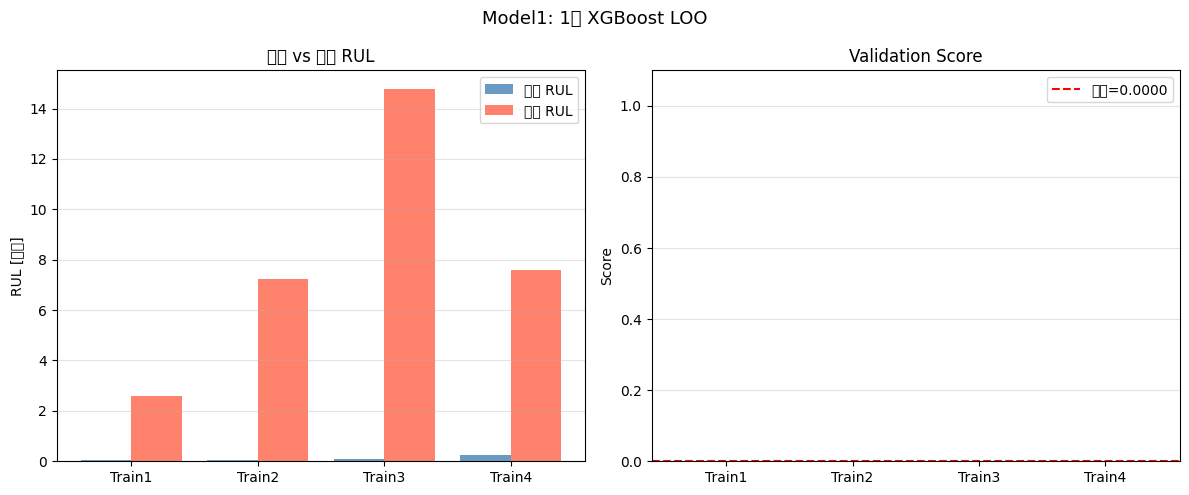

In [5]:
# ── 데이터 로드 및 트렌드 피처 추가 ──────────────────────────
df_all = load_train_data()
df_all = add_trend_features(df_all, windows=[5, 10],
                             group_col='train_id')
feat_cols = get_feat_cols(df_all)

# 트렌드 피처 포함
all_feat_cols = [c for c in df_all.columns
                 if c not in ['epoch', 'window', 't_abs', 'rpm_pred',
                               'ttf', 'RUL', 'life_pct', 'rpm',
                               'train_id', 'test_id']]

XGB_PARAMS = dict(n_estimators=500, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbosity=0)

# ── LOO 검증 ─────────────────────────────────────────────────
print('=== Model 1: 1초 단위 XGBoost LOO ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_df = df_all[df_all['train_id'] != val_id].dropna()
    val_df   = df_all[df_all['train_id'] == val_id].dropna()

    X_train  = train_df[all_feat_cols].values
    y_train  = train_df['RUL'].values
    X_val    = val_df[all_feat_cols].values
    y_val    = val_df['RUL'].values

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)

    # 마지막 시점 예측
    last_row  = val_df.loc[val_df['t_abs'].idxmax()]
    pred_rul  = float(model.predict(
        last_row[all_feat_cols].values.reshape(1, -1)
    )[0])
    pred_rul  = max(pred_rul, 0)
    act_rul   = float(last_row['RUL'])
    score     = calc_score(act_rul, pred_rul)

    mae = float(np.mean(np.abs(y_val - model.predict(X_val))))

    print(f'Val=Train{val_id} | 실제={act_rul:.0f}s '
          f'| 예측={pred_rul:.0f}s | Score={score:.4f} | MAE={mae:.0f}s')
    loo_results.append(dict(val_id=val_id, act_rul=act_rul,
                            pred_rul=pred_rul, score=score, mae=mae))

plot_loo_results(loo_results, 'Model1: 1초 XGBoost LOO', 'model1_xgb_1sec')

# ── 최종 모델 학습 ────────────────────────────────────────────
final_model = XGBRegressor(**XGB_PARAMS)
df_train_final = df_all.dropna()
final_model.fit(df_train_final[all_feat_cols].values,
                df_train_final['RUL'].values)

# ── Test 예측 ─────────────────────────────────────────────────
df_test = load_test_data()
if df_test is not None:
    df_test = add_trend_features(df_test, windows=[5, 10],
                                  group_col='test_id')
    results = []
    for tid in sorted(df_test['test_id'].unique()):
        df_t     = df_test[df_test['test_id'] == tid].dropna()
        last_row = df_t.loc[df_t['t_abs'].idxmax()]
        pred_rul = float(final_model.predict(
            last_row[all_feat_cols].values.reshape(1, -1)
        )[0])
        pred_rul = max(pred_rul, 0)
        results.append({'test_id': tid, 'pred_RUL': pred_rul})
        print(f'Test {tid} | 예측 RUL={pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

    pd.DataFrame(results).to_csv(
        '../output/model1_xgb_1sec_test.csv', index=False
    )

### 2. 1초 단위 LSTM + LOO

In [ ]:
SEQ_LEN    = 60    # 1분(60초) 시퀀스
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ── LSTM 모델 정의 ────────────────────────────────────────────
class BearingLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2,
                 dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


# ── 시퀀스 생성 ───────────────────────────────────────────────
def make_sequences(df, feat_cols, seq_len=SEQ_LEN):
    df = df.sort_values(['epoch', 'window']).reset_index(drop=True)
    X, y = [], []
    vals  = df[feat_cols].values
    rul   = df['RUL'].values

    for i in range(len(df) - seq_len + 1):
        X.append(vals[i:i+seq_len])
        y.append(rul[i+seq_len-1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# ── 학습 함수 ─────────────────────────────────────────────────
def train_lstm(X_train, y_train, input_dim):
    X_t = torch.tensor(X_train).to(DEVICE)
    y_t = torch.tensor(y_train).to(DEVICE)

    ds     = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

    model     = BearingLSTM(input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    model.train()
    for ep in range(EPOCHS):
        total_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (ep + 1) % 10 == 0:
            print(f'  Epoch {ep+1}/{EPOCHS} | Loss={total_loss/len(loader):.4f}')

    return model


# ── 데이터 로드 ───────────────────────────────────────────────
df_all    = load_train_data()
feat_cols = get_feat_cols(df_all)

# 결측 처리
df_all[feat_cols] = df_all[feat_cols].fillna(0)

# ── LOO 검증 ─────────────────────────────────────────────────
print('=== Model 2: 1초 단위 LSTM LOO ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    print(f'\n--- Val=Train{val_id} ---')
    train_df = df_all[df_all['train_id'] != val_id]
    val_df   = df_all[df_all['train_id'] == val_id]

    # 시퀀스 생성
    X_train_list, y_train_list = [], []
    for tid in [t for t in [1,2,3,4] if t != val_id]:
        X_, y_ = make_sequences(
            train_df[train_df['train_id'] == tid], feat_cols
        )
        X_train_list.append(X_)
        y_train_list.append(y_)

    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)
    X_val, y_val = make_sequences(val_df, feat_cols)

    # 정규화
    mean_ = X_train.mean(axis=(0,1), keepdims=True)
    std_  = X_train.std(axis=(0,1), keepdims=True) + 1e-10
    X_train = (X_train - mean_) / std_
    X_val   = (X_val   - mean_) / std_

    model = train_lstm(X_train, y_train, len(feat_cols))

    # 마지막 시점 예측
    model.eval()
    with torch.no_grad():
        # 마지막 SEQ_LEN개 윈도우로 예측
        last_seq = val_df.sort_values(
            ['epoch', 'window']
        ).tail(SEQ_LEN)[feat_cols].values
        last_seq = (last_seq - mean_[0]) / std_[0]
        x_t      = torch.tensor(
            last_seq[np.newaxis].astype(np.float32)
        ).to(DEVICE)
        pred_rul = float(model(x_t).cpu().numpy()[0])
        pred_rul = max(pred_rul, 0)

    act_rul = float(val_df.loc[val_df['t_abs'].idxmax(), 'RUL'])
    score   = calc_score(act_rul, pred_rul)

    print(f'실제={act_rul:.0f}s | 예측={pred_rul:.0f}s | Score={score:.4f}')
    loo_results.append(dict(val_id=val_id, act_rul=act_rul,
                            pred_rul=pred_rul, score=score))

plot_loo_results(loo_results, 'Model2: 1초 LSTM LOO', 'model2_lstm_1sec')

### 3. epoch단위 XGBoost + 트렌드 피쳐 + LOO

In [ ]:
# ── epoch 단위 집계 ───────────────────────────────────────────
def aggregate_epoch(df):
    feat_cols = get_feat_cols(df)
    agg_dict  = {c: 'median' for c in feat_cols}
    agg_dict.update({'t_abs': 'median', 'RUL': 'median',
                     'life_pct': 'median'})

    group_cols = ['train_id', 'epoch'] \
                 if 'train_id' in df.columns \
                 else ['test_id', 'epoch']

    return df.groupby(group_cols).agg(agg_dict).reset_index()


df_raw    = load_train_data()
df_epoch  = aggregate_epoch(df_raw)
df_epoch  = add_trend_features(df_epoch, windows=[3, 5],
                                group_col='train_id')

all_feat_cols = [c for c in df_epoch.columns
                 if c not in ['epoch', 't_abs', 'RUL', 'life_pct',
                               'train_id', 'test_id']]

XGB_PARAMS = dict(n_estimators=500, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbosity=0)

# ── LOO 검증 ─────────────────────────────────────────────────
print('=== Model 3: epoch 단위 XGBoost LOO ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_df = df_epoch[df_epoch['train_id'] != val_id].dropna()
    val_df   = df_epoch[df_epoch['train_id'] == val_id].dropna()

    X_train  = train_df[all_feat_cols].values
    y_train  = train_df['RUL'].values

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)

    last_row = val_df.loc[val_df['t_abs'].idxmax()]
    pred_rul = float(model.predict(
        last_row[all_feat_cols].values.reshape(1, -1)
    )[0])
    pred_rul = max(pred_rul, 0)
    act_rul  = float(last_row['RUL'])
    score    = calc_score(act_rul, pred_rul)
    mae      = float(np.mean(np.abs(
        val_df['RUL'].values -
        model.predict(val_df[all_feat_cols].values)
    )))

    print(f'Val=Train{val_id} | 실제={act_rul:.0f}s '
          f'| 예측={pred_rul:.0f}s | Score={score:.4f} | MAE={mae:.0f}s')
    loo_results.append(dict(val_id=val_id, act_rul=act_rul,
                            pred_rul=pred_rul, score=score, mae=mae))

plot_loo_results(loo_results,
                 'Model3: epoch XGBoost LOO', 'model3_xgb_epoch')

# ── 최종 모델 학습 및 Test 예측 ───────────────────────────────
final_model = XGBRegressor(**XGB_PARAMS)
df_train_final = df_epoch.dropna()
final_model.fit(df_train_final[all_feat_cols].values,
                df_train_final['RUL'].values)

df_test = load_test_data()
if df_test is not None:
    df_test_ep = aggregate_epoch(df_test)
    df_test_ep = add_trend_features(df_test_ep, windows=[3, 5],
                                     group_col='test_id')
    results = []
    for tid in sorted(df_test_ep['test_id'].unique()):
        df_t     = df_test_ep[df_test_ep['test_id'] == tid].dropna()
        last_row = df_t.loc[df_t['t_abs'].idxmax()]
        pred_rul = max(float(final_model.predict(
            last_row[all_feat_cols].values.reshape(1, -1)
        )[0]), 0)
        results.append({'test_id': tid, 'pred_RUL': pred_rul})
        print(f'Test {tid} | 예측 RUL={pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

    pd.DataFrame(results).to_csv(
        '../output/model3_xgb_epoch_test.csv', index=False
    )

4. epoch 단위 LSTM + LOO

In [ ]:
SEQ_LEN    = 10    # 최근 10 epoch 시퀀스
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class BearingLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=2,
                 dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def aggregate_epoch(df):
    feat_cols = get_feat_cols(df)
    agg_dict  = {c: 'median' for c in feat_cols}
    agg_dict.update({'t_abs': 'median', 'RUL': 'median'})
    group_cols = ['train_id', 'epoch'] \
                 if 'train_id' in df.columns \
                 else ['test_id', 'epoch']
    return df.groupby(group_cols).agg(agg_dict).reset_index()


def make_sequences(df, feat_cols, seq_len=SEQ_LEN):
    df   = df.sort_values('epoch').reset_index(drop=True)
    vals = df[feat_cols].values
    rul  = df['RUL'].values
    X, y = [], []
    for i in range(len(df) - seq_len + 1):
        X.append(vals[i:i+seq_len])
        y.append(rul[i+seq_len-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_lstm(X_train, y_train, input_dim):
    X_t    = torch.tensor(X_train).to(DEVICE)
    y_t    = torch.tensor(y_train).to(DEVICE)
    ds     = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    model  = BearingLSTM(input_dim).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=LR)
    crit   = nn.MSELoss()

    model.train()
    for ep in range(EPOCHS):
        total = 0
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item()
        if (ep + 1) % 20 == 0:
            print(f'  Epoch {ep+1}/{EPOCHS} | Loss={total/len(loader):.4f}')
    return model


# ── 데이터 준비 ───────────────────────────────────────────────
df_raw    = load_train_data()
df_epoch  = aggregate_epoch(df_raw)
feat_cols = get_feat_cols(df_epoch)
df_epoch[feat_cols] = df_epoch[feat_cols].fillna(0)

# ── LOO 검증 ─────────────────────────────────────────────────
print('=== Model 4: epoch 단위 LSTM LOO ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    print(f'\n--- Val=Train{val_id} ---')
    train_df = df_epoch[df_epoch['train_id'] != val_id]
    val_df   = df_epoch[df_epoch['train_id'] == val_id]

    X_train_list, y_train_list = [], []
    for tid in [t for t in [1,2,3,4] if t != val_id]:
        X_, y_ = make_sequences(
            train_df[train_df['train_id'] == tid], feat_cols
        )
        X_train_list.append(X_)
        y_train_list.append(y_)

    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)
    X_val, y_val = make_sequences(val_df, feat_cols)

    mean_ = X_train.mean(axis=(0,1), keepdims=True)
    std_  = X_train.std(axis=(0,1), keepdims=True) + 1e-10
    X_train = (X_train - mean_) / std_
    X_val   = (X_val   - mean_) / std_

    model = train_lstm(X_train, y_train, len(feat_cols))

    model.eval()
    with torch.no_grad():
        last_seq = val_df.sort_values('epoch').tail(SEQ_LEN)
        last_seq = (last_seq[feat_cols].values - mean_[0]) / std_[0]
        x_t      = torch.tensor(
            last_seq[np.newaxis].astype(np.float32)
        ).to(DEVICE)
        pred_rul = float(model(x_t).cpu().numpy()[0])
        pred_rul = max(pred_rul, 0)

    act_rul = float(val_df.loc[val_df['t_abs'].idxmax(), 'RUL'])
    score   = calc_score(act_rul, pred_rul)

    print(f'실제={act_rul:.0f}s | 예측={pred_rul:.0f}s | Score={score:.4f}')
    loo_results.append(dict(val_id=val_id, act_rul=act_rul,
                            pred_rul=pred_rul, score=score))

plot_loo_results(loo_results,
                 'Model4: epoch LSTM LOO', 'model4_lstm_epoch')

## 성능 비교 

In [ ]:
# 각 모델 LOO 결과 직접 입력
# (각 모델 실행 후 loo_results 값 복사)
results = {
    'Model1\n(1초 XGBoost)': [],  # loo_results 입력
    'Model2\n(1초 LSTM)':    [],
    'Model3\n(epoch XGBoost)':[],
    'Model4\n(epoch LSTM)':  [],
}

# 평균 Score 비교
avg_scores = {k: np.mean([r['score'] for r in v])
              for k, v in results.items()}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(avg_scores.keys(), avg_scores.values(),
              color=['steelblue','tomato','seagreen','darkorange'],
              alpha=0.8)

for bar, score in zip(bars, avg_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', fontsize=11)

ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='기준 0.7')
ax.set_ylim(0, 1.1)
ax.set_ylabel('평균 Score')
ax.set_title('4개 모델 성능 비교 (LOO 평균 Score)')
ax.legend()
ax.grid(True, axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('../output/model_comparison.png', bbox_inches='tight')
plt.show()

print('\n=== 최종 성능 비교 ===')
for name, score in sorted(avg_scores.items(), key=lambda x: -x[1]):
    print(f'{name}: {score:.4f}')